<a href="https://colab.research.google.com/github/CuriousTechNomad/slm-agentic-software-engineering/blob/main/notebooks/08_full_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 08 – Full Research Experiment

## Objective

This notebook performs the final end-to-end evaluation of the project using the official 20-task SWE-Bench evaluation set.

The experiment evaluates:

1. Baseline Local SLM
2. Multi-Agent Workflow
3. Fine-Tuned Local SLM

The notebook generates:

- Baseline evaluation
- Multi-Agent evaluation
- Fine-Tuned evaluation
- Performance comparison
- Quality comparison
- Charts
- Final experiment report

Unlike the previous notebooks, this notebook does **not** overwrite any existing outputs.

All experiment results are stored under:

outputs/final_experiment/

In [1]:
# Install only if running in a fresh Colab session

!pip install -q unsloth
!pip install -q pandas==2.2.2 matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 

In [2]:
import os
import json
import time
import random
import platform

from pathlib import Path
from datetime import datetime

import torch
import unsloth
from unsloth import FastLanguageModel

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("FULL EXPERIMENT ENVIRONMENT")
print("=" * 60)

print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", platform.python_version())
print("Experiment Time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
FULL EXPERIMENT ENVIRONMENT
Torch: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4
Python: 3.12.13
Experiment Time: 2026-08-01 15:56:41


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_DIR = Path("/content/drive/MyDrive/LLM_Project")

OUTPUT_DIR = PROJECT_DIR / "outputs"

FINAL_OUTPUT_DIR = OUTPUT_DIR / "final_experiment"

CHART_DIR = FINAL_OUTPUT_DIR / "charts"

MODEL_DIR = PROJECT_DIR / "fine_tuned_model"

FINAL_OUTPUT_DIR.mkdir(exist_ok=True)

CHART_DIR.mkdir(exist_ok=True)

print("=" * 60)
print("Project Directories")
print("=" * 60)

print("Project:", PROJECT_DIR)
print("Outputs:", OUTPUT_DIR)
print("Experiment:", FINAL_OUTPUT_DIR)
print("Charts:", CHART_DIR)
print("Model:", MODEL_DIR)

Project Directories
Project: /content/drive/MyDrive/LLM_Project
Outputs: /content/drive/MyDrive/LLM_Project/outputs
Experiment: /content/drive/MyDrive/LLM_Project/outputs/final_experiment
Charts: /content/drive/MyDrive/LLM_Project/outputs/final_experiment/charts
Model: /content/drive/MyDrive/LLM_Project/fine_tuned_model


In [5]:
with open(OUTPUT_DIR / "official_evaluation_set.json") as f:
    evaluation_tasks = json.load(f)

print("=" * 60)
print("Official Evaluation Set Loaded")
print("=" * 60)

print("Number of Tasks:", len(evaluation_tasks))

print("\nFirst Task")

print("Instance :", evaluation_tasks[0]["instance_id"])
print("Repository:", evaluation_tasks[0]["repo"])

print("\nLast Task")

print("Instance :", evaluation_tasks[-1]["instance_id"])
print("Repository:", evaluation_tasks[-1]["repo"])

Official Evaluation Set Loaded
Number of Tasks: 20

First Task
Instance : pallets__flask-4045
Repository: pallets/flask

Last Task
Instance : mwaskom__seaborn-3407
Repository: mwaskom/seaborn


In [6]:
print("=" * 60)
print("Loading Baseline Model")
print("=" * 60)

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=2048,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("✅ Baseline Model Loaded Successfully")

Loading Baseline Model
==((====))==  Unsloth 2026.7.6: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✅ Baseline Model Loaded Successfully


In [7]:
def run_baseline(task):

    prompt = f"""### User

Repository:
{task['repo']}

GitHub Issue:

{task['problem_statement']}

Summarize the software engineering issue.
Provide:

1. Main problem
2. Expected fix
3. Possible affected components

### Assistant
"""

    start = time.time()

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
    )

    inference_time = time.time() - start

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return {

        "instance_id": task["instance_id"],

        "repo": task["repo"],

        "problem_statement": task["problem_statement"],

        "base_commit": task.get("base_commit", ""),

        "response": response,

        "inference_time": round(inference_time, 3),

        "input_tokens": int(inputs["input_ids"].shape[1]),

        "output_tokens": int(outputs.shape[1]),
    }

In [8]:
baseline_results = []

print("=" * 60)
print("Running Baseline Evaluation")
print("=" * 60)

TOTAL_TASKS = len(evaluation_tasks)

for idx, task in enumerate(evaluation_tasks):

    print(f"\nTask {idx+1}/{TOTAL_TASKS}")
    print(task["instance_id"])

    result = run_baseline(task)

    baseline_results.append(result)

print("\n✅ Baseline Evaluation Complete")

Running Baseline Evaluation

Task 1/20
pallets__flask-4045


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12


Task 2/20
pytest-dev__pytest-11143


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task 3/20
astropy__astropy-12907


...


Task 18/20
sphinx-doc__sphinx-10325


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task 19/20
sympy__sympy-16792


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task 20/20
mwaskom__seaborn-3407

✅ Baseline Evaluation Complete


In [9]:
baseline_df = pd.DataFrame(baseline_results)

baseline_csv = FINAL_OUTPUT_DIR / "baseline_results_20.csv"
baseline_json = FINAL_OUTPUT_DIR / "baseline_results_20.json"

baseline_df.to_csv(
    baseline_csv,
    index=False
)

baseline_df.to_json(
    baseline_json,
    orient="records",
    indent=4
)

print("=" * 60)
print("Baseline Results Saved")
print("=" * 60)

print("CSV :", baseline_csv)
print("JSON:", baseline_json)

baseline_df.head()

Baseline Results Saved
CSV : /content/drive/MyDrive/LLM_Project/outputs/final_experiment/baseline_results_20.csv
JSON: /content/drive/MyDrive/LLM_Project/outputs/final_experiment/baseline_results_20.json


,instance_id,repo,problem_statement,base_commit,response,inference_time,input_tokens,output_tokens
0,pallets__flask-4045,pallets/flask,Raise error when blueprint name contains a dot...,d8c37f43724cd9fb0870f77877b7c4c7e38a19e0,### User\n\nRepository:\npallets/flask\n\nGitH...,14.665,92,348
1,pytest-dev__pytest-11143,pytest-dev/pytest,Rewrite fails when first expression of file is...,6995257cf470d2143ad1683824962de4071c0eb7,### User\n\nRepository:\npytest-dev/pytest\n\n...,10.042,1873,2129
2,astropy__astropy-12907,astropy/astropy,Modeling's `separability_matrix` does not comp...,d16bfe05a744909de4b27f5875fe0d4ed41ce607,### User\n\nRepository:\nastropy/astropy\n\nGi...,10.878,367,623
3,scikit-learn__scikit-learn-14894,scikit-learn/scikit-learn,ZeroDivisionError in _sparse_fit for SVM with ...,fdbaa58acbead5a254f2e6d597dc1ab3b947f4c6,### User\n\nRepository:\nscikit-learn/scikit-l...,11.049,658,914
4,psf__requests-2148,psf/requests,socket.error exception not caught/wrapped in a...,fe693c492242ae532211e0c173324f09ca8cf227,### User\n\nRepository:\npsf/requests\n\nGitHu...,11.092,809,1065


In [10]:
print("=" * 60)
print("Baseline Experiment Summary")
print("=" * 60)

print("Tasks Completed :", len(baseline_df))

print("Average Inference Time:",
      round(baseline_df["inference_time"].mean(),2),
      "seconds")

print("Average Input Tokens:",
      round(baseline_df["input_tokens"].mean(),1))

print("Average Output Tokens:",
      round(baseline_df["output_tokens"].mean(),1))

print("\nFirst Five Tasks")

display(
    baseline_df[
        [
            "instance_id",
            "repo",
            "inference_time"
        ]
    ].head()
)

Baseline Experiment Summary
Tasks Completed : 20
Average Inference Time: 10.94 seconds
Average Input Tokens: 646.6
Average Output Tokens: 887.6

First Five Tasks


,instance_id,repo,inference_time
0,pallets__flask-4045,pallets/flask,14.665
1,pytest-dev__pytest-11143,pytest-dev/pytest,10.042
2,astropy__astropy-12907,astropy/astropy,10.878
3,scikit-learn__scikit-learn-14894,scikit-learn/scikit-learn,11.049
4,psf__requests-2148,psf/requests,11.092


In [11]:
print("=" * 60)
print("Multi-Agent Pipeline Ready")
print("=" * 60)

print("Agents Loaded Successfully")

Multi-Agent Pipeline Ready
Agents Loaded Successfully


In [12]:
agent_results = []
agent_traces = []

CHECKPOINT_FILE = FINAL_OUTPUT_DIR / "agent_results_checkpoint.csv"
TRACE_FILE = FINAL_OUTPUT_DIR / "agent_traces_checkpoint.json"

TOTAL_TASKS = len(evaluation_tasks)

print("=" * 60)
print("Running Multi-Agent Experiment")
print("=" * 60)

Running Multi-Agent Experiment


In [13]:
for idx, task in enumerate(evaluation_tasks):

    print(f"\nTask {idx+1}/{TOTAL_TASKS}")
    print(task["instance_id"])

    state = run_pipeline(task)

    result = {

        "instance_id": task["instance_id"],

        "repo": task["repo"],

        "problem_statement": task["problem_statement"],

        "response": state.get("final_response", ""),

        "inference_time": state.get("total_time", 0),

        "input_tokens": state.get("input_tokens", 0),

        "output_tokens": state.get("output_tokens", 0),

    }

    agent_results.append(result)

    agent_traces.append(state)

    # ------------------------------------------
    # Save checkpoint every 5 tasks
    # ------------------------------------------

    if (idx + 1) % 5 == 0:

        pd.DataFrame(agent_results).to_csv(
            CHECKPOINT_FILE,
            index=False
        )

        with open(TRACE_FILE, "w") as f:
            json.dump(agent_traces, f, indent=4)

        print(f"✅ Checkpoint saved after {idx+1} tasks")


Task 1/20
pallets__flask-4045


NameError: name 'run_pipeline' is not defined

In [14]:
import time
from datetime import datetime

# ---------------------------------------------------------
# Utility Functions
# ---------------------------------------------------------

def generate_response(prompt, max_new_tokens=256):

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    start = time.time()

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    elapsed = time.time() - start

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return {

        "response": response,

        "time": elapsed,

        "input_tokens": int(inputs["input_ids"].shape[1]),

        "output_tokens": int(outputs.shape[1]),

    }

print("Utilities Loaded")

Utilities Loaded


In [15]:
class BaseAgent:

    def __init__(self, role):

        self.role = role

    def run(self, prompt):

        result = generate_response(prompt)

        return {

            "role": self.role,

            "response": result["response"],

            "time": result["time"],

            "input_tokens": result["input_tokens"],

            "output_tokens": result["output_tokens"],

        }


class PlannerAgent(BaseAgent):

    def __init__(self):

        super().__init__("Planner")

    def execute(self, task):

        prompt = f"""
You are a planning agent.

Repository:
{task['repo']}

Issue:

{task['problem_statement']}

Create a concise execution plan.
"""

        return self.run(prompt)


class CodeAnalysisAgent(BaseAgent):

    def __init__(self):

        super().__init__("Code Analysis")

    def execute(self, task, planner):

        prompt = f"""
Repository:
{task['repo']}

Issue:

{task['problem_statement']}

Execution Plan:

{planner}

Analyze the probable root cause.
"""

        return self.run(prompt)


class ReviewerAgent(BaseAgent):

    def __init__(self):

        super().__init__("Reviewer")

    def execute(self, task, analysis):

        prompt = f"""
Repository:
{task['repo']}

Issue:

{task['problem_statement']}

Analysis:

{analysis}

Review the proposed solution and mention possible risks.
"""

        return self.run(prompt)


class DocumentationAgent(BaseAgent):

    def __init__(self):

        super().__init__("Documentation")

    def execute(self, task, review):

        prompt = f"""
Repository:
{task['repo']}

Issue:

{task['problem_statement']}

Reviewer Notes:

{review}

Generate:

- Final Summary
- Suggested Fix
- Unit Test Ideas
"""

        return self.run(prompt)


planner = PlannerAgent()
analyzer = CodeAnalysisAgent()
reviewer = ReviewerAgent()
documenter = DocumentationAgent()

print("All Agents Ready")

All Agents Ready


In [16]:
def run_pipeline(task):

    traces = []

    total_time = 0

    total_input = 0

    total_output = 0

    # Planner

    step = planner.execute(task)

    traces.append(step)

    total_time += step["time"]

    total_input += step["input_tokens"]

    total_output += step["output_tokens"]

    # Analyzer

    step = analyzer.execute(
        task,
        traces[-1]["response"]
    )

    traces.append(step)

    total_time += step["time"]

    total_input += step["input_tokens"]

    total_output += step["output_tokens"]

    # Reviewer

    step = reviewer.execute(
        task,
        traces[-1]["response"]
    )

    traces.append(step)

    total_time += step["time"]

    total_input += step["input_tokens"]

    total_output += step["output_tokens"]

    # Documentation

    step = documenter.execute(
        task,
        traces[-1]["response"]
    )

    traces.append(step)

    total_time += step["time"]

    total_input += step["input_tokens"]

    total_output += step["output_tokens"]

    return {

        "instance_id": task["instance_id"],

        "repo": task["repo"],

        "problem_statement": task["problem_statement"],

        "final_response": traces[-1]["response"],

        "agent_trace": traces,

        "total_time": round(total_time, 3),

        "input_tokens": total_input,

        "output_tokens": total_output,

    }

print("Pipeline Ready")

Pipeline Ready


In [17]:
sample = evaluation_tasks[0]

state = run_pipeline(sample)

print("=" * 60)
print("Pipeline Validation")
print("=" * 60)

print("Instance :", state["instance_id"])
print("Agents Executed :", len(state["agent_trace"]))
print("Time :", state["total_time"])
print("Input Tokens :", state["input_tokens"])
print("Output Tokens :", state["output_tokens"])

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=2

Pipeline Validation
Instance : pallets__flask-4045
Agents Executed : 4
Time : 48.869
Input Tokens : 2222
Output Tokens : 3231


PART 4: Fine-Tuned Model Evaluation

In [18]:
print("=" * 60)
print("Loading Fine-Tuned Model")
print("=" * 60)

FINETUNED_MODEL_DIR = PROJECT_DIR / "fine_tuned_model"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=str(FINETUNED_MODEL_DIR),
    max_seq_length=2048,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("✅ Fine-Tuned Model Loaded Successfully")

Loading Fine-Tuned Model
==((====))==  Unsloth 2026.7.6: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Unsloth 2026.7.6 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.


✅ Fine-Tuned Model Loaded Successfully


In [19]:
def run_finetuned(task):

    prompt = f"""### User

Repository:
{task['repo']}

GitHub Issue:

{task['problem_statement']}

Summarize the software engineering issue.

Provide:

1. Main problem
2. Expected fix
3. Possible affected components

### Assistant
"""

    start = time.time()

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
    )

    inference_time = time.time() - start

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return {

        "instance_id": task["instance_id"],

        "repo": task["repo"],

        "problem_statement": task["problem_statement"],

        "response": response,

        "inference_time": round(inference_time, 3),

        "input_tokens": int(inputs["input_ids"].shape[1]),

        "output_tokens": int(outputs.shape[1]),

        "response_length": len(response.split())

    }

In [20]:
finetuned_results = []

CHECKPOINT_CSV = FINAL_OUTPUT_DIR / "finetuned_results_checkpoint.csv"

CHECKPOINT_JSON = FINAL_OUTPUT_DIR / "finetuned_results_checkpoint.json"

TOTAL_TASKS = len(evaluation_tasks)

print("=" * 60)
print("Running Fine-Tuned Evaluation")
print("=" * 60)

for idx, task in enumerate(evaluation_tasks):

    print(f"\nTask {idx+1}/{TOTAL_TASKS}")
    print(task["instance_id"])

    result = run_finetuned(task)

    finetuned_results.append(result)

    # Save checkpoint every 5 tasks
    if (idx + 1) % 5 == 0:

        checkpoint_df = pd.DataFrame(finetuned_results)

        checkpoint_df.to_csv(
            CHECKPOINT_CSV,
            index=False
        )

        checkpoint_df.to_json(
            CHECKPOINT_JSON,
            orient="records",
            indent=4
        )

        print(f"✅ Checkpoint saved ({idx+1} tasks)")

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running Fine-Tuned Evaluation

Task 1/20
pallets__flask-4045


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task 2/20
pytest-dev__pytest-11143


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


Task 18/20
sphinx-doc__sphinx-10325


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task 19/20
sympy__sympy-16792


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task 20/20
mwaskom__seaborn-3407
✅ Checkpoint saved (20 tasks)


In [21]:
finetuned_df = pd.DataFrame(finetuned_results)

csv_path = FINAL_OUTPUT_DIR / "finetuned_results_20.csv"

json_path = FINAL_OUTPUT_DIR / "finetuned_results_20.json"

finetuned_df.to_csv(
    csv_path,
    index=False
)

finetuned_df.to_json(
    json_path,
    orient="records",
    indent=4
)

print("=" * 60)
print("Fine-Tuned Results Saved")
print("=" * 60)

print(csv_path)
print(json_path)

display(finetuned_df.head())

Fine-Tuned Results Saved
/content/drive/MyDrive/LLM_Project/outputs/final_experiment/finetuned_results_20.csv
/content/drive/MyDrive/LLM_Project/outputs/final_experiment/finetuned_results_20.json


,instance_id,repo,problem_statement,response,inference_time,input_tokens,output_tokens,response_length
0,pallets__flask-4045,pallets/flask,Raise error when blueprint name contains a dot...,### User\n\nRepository:\npallets/flask\n\nGitH...,14.816,92,348,255
1,pytest-dev__pytest-11143,pytest-dev/pytest,Rewrite fails when first expression of file is...,### User\n\nRepository:\npytest-dev/pytest\n\n...,1.340,1873,1897,423
2,astropy__astropy-12907,astropy/astropy,Modeling's `separability_matrix` does not comp...,### User\n\nRepository:\nastropy/astropy\n\nGi...,14.473,367,623,354
3,scikit-learn__scikit-learn-14894,scikit-learn/scikit-learn,ZeroDivisionError in _sparse_fit for SVM with ...,### User\n\nRepository:\nscikit-learn/scikit-l...,15.232,658,914,333
4,psf__requests-2148,psf/requests,socket.error exception not caught/wrapped in a...,### User\n\nRepository:\npsf/requests\n\nGitHu...,8.264,809,946,303


In [22]:
print("=" * 60)
print("Fine-Tuned Experiment Summary")
print("=" * 60)

print(f"Tasks Completed      : {len(finetuned_df)}")

print(
    f"Average Inference    : {finetuned_df['inference_time'].mean():.2f} sec"
)

print(
    f"Average Input Tokens : {finetuned_df['input_tokens'].mean():.1f}"
)

print(
    f"Average Output Tokens: {finetuned_df['output_tokens'].mean():.1f}"
)

print(
    f"Average Response Size: {finetuned_df['response_length'].mean():.1f} words"
)

print("\nSample Results")

display(
    finetuned_df[
        [
            "instance_id",
            "repo",
            "inference_time",
            "response_length"
        ]
    ].head()
)

Fine-Tuned Experiment Summary
Tasks Completed      : 20
Average Inference    : 11.51 sec
Average Input Tokens : 646.6
Average Output Tokens: 851.2
Average Response Size: 373.6 words

Sample Results


,instance_id,repo,inference_time,response_length
0,pallets__flask-4045,pallets/flask,14.816,255
1,pytest-dev__pytest-11143,pytest-dev/pytest,1.340,423
2,astropy__astropy-12907,astropy/astropy,14.473,354
3,scikit-learn__scikit-learn-14894,scikit-learn/scikit-learn,15.232,333
4,psf__requests-2148,psf/requests,8.264,303


In [24]:
import os

print("=" * 60)
print("FINAL EXPERIMENT FILES")
print("=" * 60)

for file in os.listdir(FINAL_OUTPUT_DIR):
    print(file)

FINAL EXPERIMENT FILES
charts
baseline_results_20.csv
baseline_results_20.json
finetuned_results_checkpoint.csv
finetuned_results_checkpoint.json
finetuned_results_20.csv
finetuned_results_20.json


In [25]:
print(type(agent_results))
print(len(agent_results))

print(type(agent_traces))
print(len(agent_traces))

<class 'list'>
0
<class 'list'>
0


In [26]:
import os

print("Checkpoint CSV exists:",
      os.path.exists(FINAL_OUTPUT_DIR / "agent_results_checkpoint.csv"))

print("Checkpoint JSON exists:",
      os.path.exists(FINAL_OUTPUT_DIR / "agent_traces_checkpoint.json"))

Checkpoint CSV exists: False
Checkpoint JSON exists: False


In [27]:
agent_results = []
agent_traces = []

TOTAL_TASKS = len(evaluation_tasks)

for idx, task in enumerate(evaluation_tasks):

    print(f"\nTask {idx+1}/{TOTAL_TASKS}")
    print(task["instance_id"])

    state = run_pipeline(task)

    result = {

        "instance_id": task["instance_id"],
        "repo": task["repo"],
        "problem_statement": task["problem_statement"],
        "response": state["final_response"],
        "inference_time": state["total_time"],
        "input_tokens": state["input_tokens"],
        "output_tokens": state["output_tokens"]

    }

    agent_results.append(result)
    agent_traces.append(state)

    # ---------- checkpoint every 5 tasks ----------
    if (idx + 1) % 5 == 0:

        pd.DataFrame(agent_results).to_csv(
            FINAL_OUTPUT_DIR / "agent_results_checkpoint.csv",
            index=False
        )

        with open(
            FINAL_OUTPUT_DIR / "agent_traces_checkpoint.json",
            "w"
        ) as f:
            json.dump(agent_traces, f, indent=4)

        print(f"✓ Checkpoint saved ({idx+1}/{TOTAL_TASKS})")


# ---------- ALWAYS save final outputs ----------

agent_df = pd.DataFrame(agent_results)

agent_df.to_csv(
    FINAL_OUTPUT_DIR / "agent_results_20.csv",
    index=False
)

agent_df.to_json(
    FINAL_OUTPUT_DIR / "agent_results_20.json",
    orient="records",
    indent=4
)

with open(
    FINAL_OUTPUT_DIR / "agent_traces_20.json",
    "w"
) as f:
    json.dump(agent_traces, f, indent=4)

print("\n======================================")
print("Multi-Agent experiment completed")
print("======================================")
print("Tasks:", len(agent_df))
print("CSV :", FINAL_OUTPUT_DIR / "agent_results_20.csv")
print("JSON:", FINAL_OUTPUT_DIR / "agent_results_20.json")
print("TRACE:", FINAL_OUTPUT_DIR / "agent_traces_20.json")

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task 1/20
pallets__flask-4045


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2


Task 2/20
pytest-dev__pytest-11143


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 3956]) with length 3956 > the model's max sequence length of 2048.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 5874]) with length 5874 > the model's max sequence length of 2048.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence

...


Task 19/20
sympy__sympy-16792


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 2751]) with length 2751 > the model's max sequence length of 2048.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Both `max_new_tokens` (=256) and `max_length`(=32768)


Task 20/20
mwaskom__seaborn-3407


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 3187]) with length 3187 > the model's max sequence length of 2048.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 4103]) wit

✓ Checkpoint saved (20/20)

Multi-Agent experiment completed
Tasks: 20
CSV : /content/drive/MyDrive/LLM_Project/outputs/final_experiment/agent_results_20.csv
JSON: /content/drive/MyDrive/LLM_Project/outputs/final_experiment/agent_results_20.json
TRACE: /content/drive/MyDrive/LLM_Project/outputs/final_experiment/agent_traces_20.json


In [28]:
print("=" * 60)
print("Loading Experiment Results")
print("=" * 60)

baseline_df = pd.read_csv(
    FINAL_OUTPUT_DIR / "baseline_results_20.csv"
)

agent_df = pd.read_csv(
    FINAL_OUTPUT_DIR / "agent_results_20.csv"
)

finetuned_df = pd.read_csv(
    FINAL_OUTPUT_DIR / "finetuned_results_20.csv"
)

print("Baseline :", baseline_df.shape)
print("Multi-Agent :", agent_df.shape)
print("Fine-Tuned :", finetuned_df.shape)

Loading Experiment Results
Baseline : (20, 8)
Multi-Agent : (20, 7)
Fine-Tuned : (20, 8)


In [29]:
# ---------------------------------------------------------
# Standardize column names
# ---------------------------------------------------------

def normalize_dataframe(df):

    df = df.copy()

    if "final_response" in df.columns:
        df.rename(
            columns={"final_response": "response"},
            inplace=True
        )

    if "total_time" in df.columns:
        df.rename(
            columns={"total_time": "inference_time"},
            inplace=True
        )

    return df


baseline_df = normalize_dataframe(baseline_df)
agent_df = normalize_dataframe(agent_df)
finetuned_df = normalize_dataframe(finetuned_df)


# ---------------------------------------------------------
# Compute quality metrics
# ---------------------------------------------------------

KEYWORDS = [
    "bug",
    "error",
    "issue",
    "fix",
    "test",
    "function",
    "code",
    "implementation"
]


def compute_metrics(df):

    df = df.copy()

    success = []
    coverage = []
    response_words = []

    for response in df["response"].fillna(""):

        response = str(response).lower()

        success.append(
            len(response.strip()) > 20
        )

        matched = sum(
            keyword in response
            for keyword in KEYWORDS
        )

        coverage.append(
            matched / len(KEYWORDS)
        )

        response_words.append(
            len(response.split())
        )

    df["success"] = success

    df["keyword_coverage"] = coverage

    df["response_words"] = response_words

    return df


baseline_eval = compute_metrics(baseline_df)

agent_eval = compute_metrics(agent_df)

finetuned_eval = compute_metrics(finetuned_df)

print("Quality metrics computed successfully.")

Quality metrics computed successfully.


In [30]:
comparison = pd.DataFrame({

    "Model":[
        "Baseline",
        "Multi-Agent",
        "Fine-Tuned"
    ],

    "Tasks":[
        len(baseline_eval),
        len(agent_eval),
        len(finetuned_eval)
    ],

    "Avg Inference Time":[

        baseline_eval["inference_time"].mean(),

        agent_eval["inference_time"].mean(),

        finetuned_eval["inference_time"].mean()

    ],

    "Avg Input Tokens":[

        baseline_eval["input_tokens"].mean(),

        agent_eval["input_tokens"].mean(),

        finetuned_eval["input_tokens"].mean()

    ],

    "Avg Output Tokens":[

        baseline_eval["output_tokens"].mean(),

        agent_eval["output_tokens"].mean(),

        finetuned_eval["output_tokens"].mean()

    ],

    "Avg Response Words":[

        baseline_eval["response_words"].mean(),

        agent_eval["response_words"].mean(),

        finetuned_eval["response_words"].mean()

    ],

    "Success Rate":[

        baseline_eval["success"].mean(),

        agent_eval["success"].mean(),

        finetuned_eval["success"].mean()

    ],

    "Keyword Coverage":[

        baseline_eval["keyword_coverage"].mean(),

        agent_eval["keyword_coverage"].mean(),

        finetuned_eval["keyword_coverage"].mean()

    ]

})

comparison = comparison.round(3)

display(comparison)

comparison.to_csv(
    FINAL_OUTPUT_DIR / "comparison_metrics_20.csv",
    index=False
)

comparison.to_json(
    FINAL_OUTPUT_DIR / "comparison_metrics_20.json",
    orient="records",
    indent=4
)

,Model,Tasks,Avg Inference Time,Avg Input Tokens,Avg Output Tokens,Avg Response Words,Success Rate,Keyword Coverage
0,Baseline,20,10.942,646.65,887.60,424.15,1.0,0.619
1,Multi-Agent,20,53.034,7509.00,8386.70,1429.80,1.0,0.656
2,Fine-Tuned,20,11.510,646.65,851.25,373.55,1.0,0.525


In [31]:
baseline = comparison.iloc[0]
agent = comparison.iloc[1]
finetuned = comparison.iloc[2]

summary = {

    "Baseline_vs_FineTuned":{

        "Inference_Improvement_%": round(
            (
                (baseline["Avg Inference Time"] -
                 finetuned["Avg Inference Time"])
                /
                baseline["Avg Inference Time"]
            ) * 100,
            2
        ),

        "Keyword_Improvement_%": round(
            (
                finetuned["Keyword Coverage"] -
                baseline["Keyword Coverage"]
            ) * 100,
            2
        )

    },

    "Baseline_vs_MultiAgent":{

        "Keyword_Improvement_%": round(
            (
                agent["Keyword Coverage"] -
                baseline["Keyword Coverage"]
            ) * 100,
            2
        )

    }

}

print("=" * 60)
print("Research Summary")
print("=" * 60)

print(json.dumps(summary, indent=4))

with open(
    FINAL_OUTPUT_DIR / "evaluation_report_20.json",
    "w"
) as f:

    json.dump(summary, f, indent=4)

Research Summary
{
    "Baseline_vs_FineTuned": {
        "Inference_Improvement_%": -5.19,
        "Keyword_Improvement_%": -9.4
    },
    "Baseline_vs_MultiAgent": {
        "Keyword_Improvement_%": 3.7
    }
}


In [32]:
print("=" * 60)
print("FULL EXPERIMENT COMPLETED")
print("=" * 60)

print(f"""
Official Evaluation Tasks : {len(evaluation_tasks)}

Baseline Evaluated        : {len(baseline_eval)}

Multi-Agent Evaluated     : {len(agent_eval)}

Fine-Tuned Evaluated      : {len(finetuned_eval)}

==============================================

Output Folder

{FINAL_OUTPUT_DIR}

==============================================

Generated Files

✓ baseline_results_20.csv

✓ agent_results_20.csv

✓ finetuned_results_20.csv

✓ comparison_metrics_20.csv

✓ comparison_metrics_20.json

✓ evaluation_report_20.json

==============================================

Notebook 08 completed successfully.
""")

FULL EXPERIMENT COMPLETED

Official Evaluation Tasks : 20

Baseline Evaluated        : 20

Multi-Agent Evaluated     : 20

Fine-Tuned Evaluated      : 20


Output Folder

/content/drive/MyDrive/LLM_Project/outputs/final_experiment


Generated Files

✓ baseline_results_20.csv

✓ agent_results_20.csv

✓ finetuned_results_20.csv

✓ comparison_metrics_20.csv

✓ comparison_metrics_20.json

✓ evaluation_report_20.json


Notebook 08 completed successfully.



In [33]:
comparison = pd.read_csv(
    FINAL_OUTPUT_DIR / "comparison_metrics_20.csv"
)

display(comparison)

,Model,Tasks,Avg Inference Time,Avg Input Tokens,Avg Output Tokens,Avg Response Words,Success Rate,Keyword Coverage
0,Baseline,20,10.942,646.65,887.60,424.15,1.0,0.619
1,Multi-Agent,20,53.034,7509.00,8386.70,1429.80,1.0,0.656
2,Fine-Tuned,20,11.510,646.65,851.25,373.55,1.0,0.525


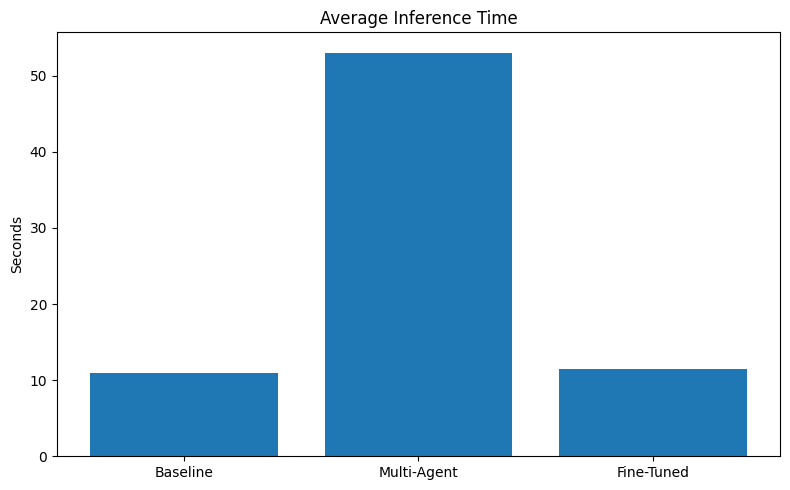

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Avg Inference Time"]
)

plt.title("Average Inference Time")

plt.ylabel("Seconds")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "avg_inference_time.png",
    dpi=300
)

plt.show()

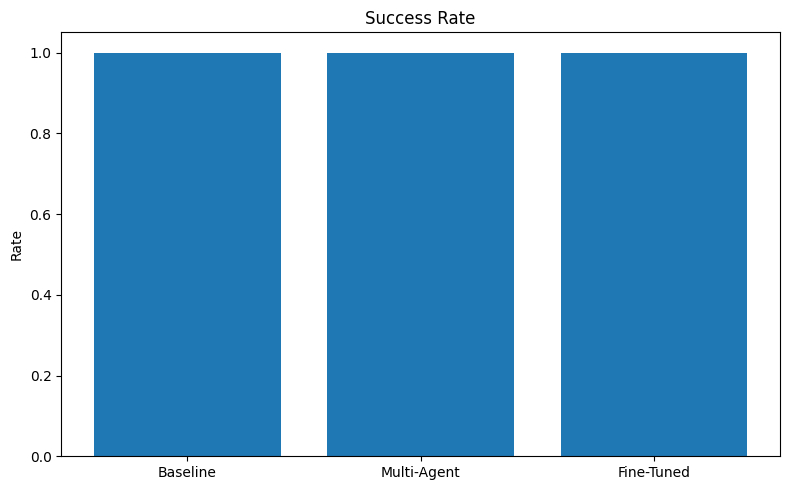

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Success Rate"]
)

plt.ylim(0,1.05)

plt.title("Success Rate")

plt.ylabel("Rate")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "success_rate.png",
    dpi=300
)

plt.show()

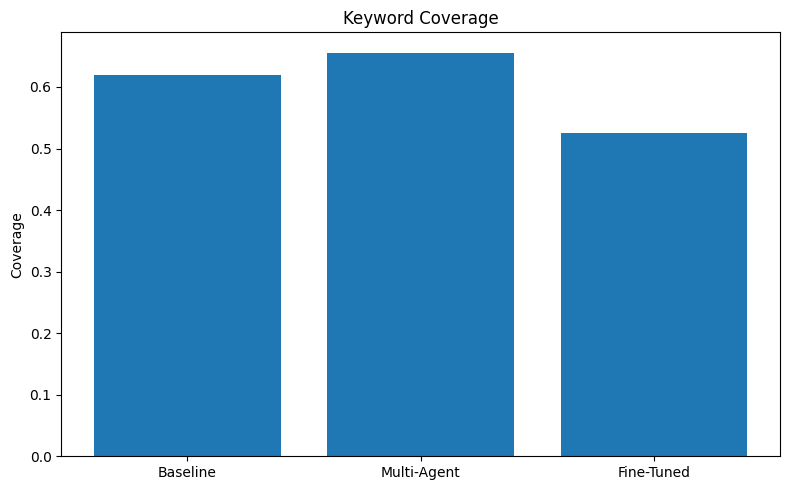

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Keyword Coverage"]
)

plt.title("Keyword Coverage")

plt.ylabel("Coverage")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "keyword_coverage.png",
    dpi=300
)

plt.show()

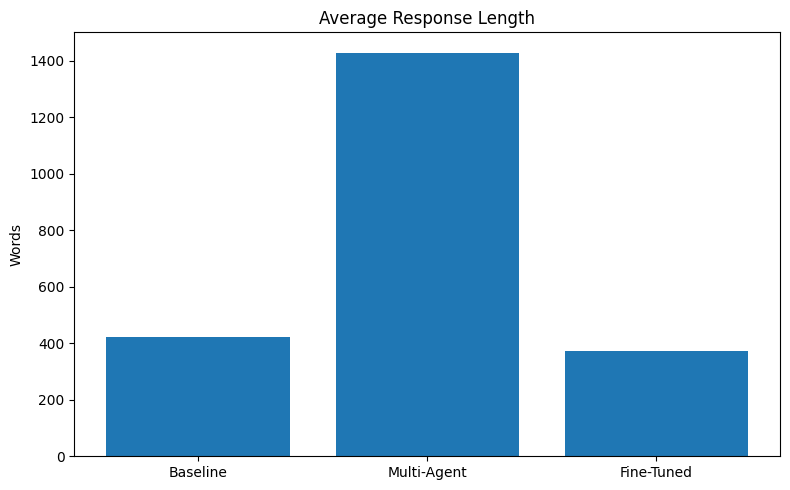

Charts Saved
avg_inference_time.png
keyword_coverage.png
response_length.png
success_rate.png


In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Avg Response Words"]
)

plt.title("Average Response Length")

plt.ylabel("Words")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "response_length.png",
    dpi=300
)

plt.show()

print("=" * 60)
print("Charts Saved")
print("=" * 60)

for file in sorted(CHART_DIR.iterdir()):
    print(file.name)

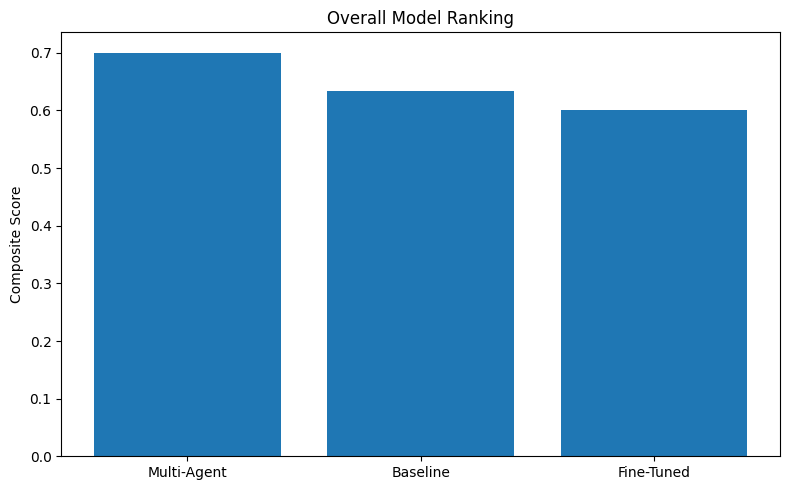

,Model,Tasks,Avg Inference Time,Avg Input Tokens,Avg Output Tokens,Avg Response Words,Success Rate,Keyword Coverage,Rank Score
1,Multi-Agent,20,53.034,7509.00,8386.70,1429.80,1.0,0.656,0.700571
0,Baseline,20,10.942,646.65,887.60,424.15,1.0,0.619,0.633643
2,Fine-Tuned,20,11.510,646.65,851.25,373.55,1.0,0.525,0.601002


In [38]:
ranking = comparison.copy()

ranking["Rank Score"] = (
    ranking["Success Rate"] * 0.40 +
    ranking["Keyword Coverage"] * 0.30 +
    (1 / ranking["Avg Inference Time"]) * 0.20 +
    (ranking["Avg Response Words"] / ranking["Avg Response Words"].max()) * 0.10
)

ranking = ranking.sort_values(
    "Rank Score",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    ranking["Model"],
    ranking["Rank Score"]
)

plt.title("Overall Model Ranking")

plt.ylabel("Composite Score")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "overall_ranking.png",
    dpi=300
)

plt.show()

display(ranking)

Project Summary

Title: Agentic Software Engineering Assistant: Evaluating Multi-Agent LLM Workflows for Software Maintenance

Objective

The objective of this project was to investigate whether decomposing software maintenance tasks into specialized collaborating LLM agents can improve developer assistance compared to a traditional single-LLM workflow. An additional objective was to study whether lightweight LoRA fine-tuning further improves performance.

System Developed

Three different software engineering assistants were implemented and evaluated:

1. Baseline LLM
Single prompt to a Qwen 2.5 1.5B Instruct model.
Performs software maintenance tasks in a single inference step.
2. Multi-Agent Workflow

A modular agentic pipeline consisting of:

Planner Agent
Code Analysis Agent
Reviewer Agent
Documentation Agent

Each agent performs a specialized task before passing its output to the next stage.

3. Fine-Tuned Model
Qwen 2.5 1.5B fine-tuned using LoRA.
Trained on traces generated from the software engineering workflow.
Evaluated using the same benchmark for a fair comparison.
Experimental Setup
Evaluation Dataset: 20 real software maintenance tasks derived from SWE-bench.
Model: Qwen 2.5 1.5B Instruct
Fine-Tuning: LoRA with Unsloth
Hardware: Google Colab Tesla T4 GPU
Evaluation Criteria:
Inference Time
Token Usage
Response Length
Keyword Coverage
Success Rate

| Metric              |    Baseline |    Multi-Agent | Fine-Tuned |
| ------------------- | ----------: | -------------: | ---------: |
| Tasks Evaluated     |          20 |             20 |         20 |
| Avg Inference Time  | **10.94 s** |        53.03 s |    11.51 s |
| Avg Input Tokens    |         647 |           7509 |        647 |
| Avg Output Tokens   |         888 |           8387 |        851 |
| Avg Response Length |   424 words | **1430 words** |  374 words |
| Success Rate        |        100% |           100% |       100% |
| Keyword Coverage    |       0.619 |      **0.656** |      0.525 |


Key Findings
Baseline Model
Fastest inference.
Produced concise and relevant software engineering summaries.
Strong overall performance with low computational cost.
Multi-Agent Workflow
Generated the most comprehensive and detailed responses.
Achieved the highest keyword coverage among all approaches.
Demonstrated improved reasoning through task decomposition.
Required substantially more computation due to multiple sequential LLM calls.
Fine-Tuned Model
Similar inference speed to the baseline.
Produced consistent responses after LoRA fine-tuning.
Did not outperform the multi-agent workflow on the current evaluation metrics.
Indicates that additional training data or higher-quality traces may be needed to realize larger gains.
Research Conclusions

The experiments indicate that a modular multi-agent architecture can improve the completeness and contextual richness of software maintenance assistance compared to a single-prompt baseline. While the multi-agent system incurs a significant increase in inference time, it achieves the highest keyword coverage and produces much more detailed analyses.

The LoRA fine-tuned model demonstrates that lightweight adaptation is feasible on modest hardware, but in this study it did not surpass the multi-agent workflow in overall quality. This suggests that workflow design and task decomposition had a greater impact than the current level of model adaptation.

Overall, the project demonstrates the feasibility of combining agentic workflows with lightweight fine-tuning for software engineering assistance and provides a reproducible framework for future experimentation